# Practicum 2 — Regressieanalyse Bike Sharing Dataset

## 1. Introductie

Het doel van dit project is het ontwikkelen, evalueren en deployen van een regressiemodel dat het **totaal aantal fietsverhuren per uur** (`cnt`) voorspelt op basis van weer-, seizoens- en tijdsinformatie.

De dataset is afkomstig van het UCI Machine Learning Repository en bevat 17.379 uurlijkse observaties van het Capital Bikeshare-systeem in Washington D.C. over de jaren 2011 en 2012.

**Waarom is deze dataset geschikt voor regressie?**
- De target variabele `cnt` is continu (numeriek), wat een vereiste is voor regressie
- De dataset bevat meer dan 3.000 rijen (17.379)
- Er zijn meer dan 10 onafhankelijke variabelen beschikbaar
- De data komt van het UCI Machine Learning Repository, een goedgekeurde bron

**Belangrijke opmerking over data leakage:**  
De kolommen `casual` en `registered` worden uitgesloten als features, aangezien `cnt = casual + registered`. Het meenemen hiervan zou leiden tot data leakage.

**Bron:** [UCI Machine Learning Repository — Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

## 2. Datasetbeschrijving

De Bike Sharing Dataset bevat uurlijkse tellingen van fietsverhuren van het Capital Bikeshare-systeem in Washington D.C., gecombineerd met bijbehorende weer- en seizoensinformatie.

### Data Dictionary

| Variabele | Type | Beschrijving | Mogelijke waarden |
|-----------|------|-------------|-------------------|
| `instant` | int | Rij-index | 1–17379 |
| `dteday` | string | Datum | 2011-01-01 t/m 2012-12-31 |
| `season` | int (categorisch) | Seizoen | 1=lente, 2=zomer, 3=herfst, 4=winter |
| `yr` | int (categorisch) | Jaar | 0=2011, 1=2012 |
| `mnth` | int (categorisch) | Maand | 1–12 |
| `hr` | int (categorisch) | Uur van de dag | 0–23 |
| `holiday` | int (categorisch) | Feestdag | 0=nee, 1=ja |
| `weekday` | int (categorisch) | Dag van de week | 0=zondag t/m 6=zaterdag |
| `workingday` | int (categorisch) | Werkdag | 0=nee, 1=ja |
| `weathersit` | int (categorisch) | Weersituatie | 1=helder, 2=bewolkt, 3=lichte regen/sneeuw, 4=zwaar weer |
| `temp` | float | Genormaliseerde temperatuur | 0–1 (werkelijk: -8°C tot 39°C) |
| `atemp` | float | Genormaliseerde gevoelstemperatuur | 0–1 (werkelijk: -16°C tot 50°C) |
| `hum` | float | Genormaliseerde luchtvochtigheid | 0–1 |
| `windspeed` | float | Genormaliseerde windsnelheid | 0–1 |
| `casual` | int | Aantal niet-geregistreerde gebruikers | ⚠ Uitgesloten (leakage) |
| `registered` | int | Aantal geregistreerde gebruikers | ⚠ Uitgesloten (leakage) |
| `cnt` | int | **Totaal aantal fietsverhuren (TARGET)** | 1–977 |

### Variabelen die worden uitgesloten

- **`instant`** — rij-index, geen voorspellende waarde
- **`dteday`** — datum als string, niet direct bruikbaar als feature
- **`casual`** en **`registered`** — samen vormen zij `cnt`, dus meenemen leidt tot data leakage

### Features die worden gebruikt voor het model

Na uitsluiting blijven **10 onafhankelijke variabelen** over:  
`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`

## 3. Data Loading and Initial Inspection

In [761]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [762]:
# Dataset inladen
df = pd.read_csv('../data/hour.csv')

# Eerste 5 rijen bekijken
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [763]:
# Shape van de dataset
print(f"Aantal rijen: {df.shape[0]}")
print(f"Aantal kolommen: {df.shape[1]}")
print()

# Datatypes
print(df.dtypes)

Aantal rijen: 17379
Aantal kolommen: 17

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [764]:
# Missing values controleren
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotaal missing values: {df.isnull().sum().sum()}")

Missing values per kolom:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Totaal missing values: 0


In [765]:
# Beschrijvende statistieken
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 4. Preprocessing

In deze stap bereiden we de data voor op modellering:
1. Verwijderen van kolommen die niet gebruikt mogen worden (leakage, index, datum)
2. Identificeren van categorische en numerieke features
3. Controleren of verdere preprocessing nodig is

In [766]:
# Kolommen verwijderen die niet als feature gebruikt mogen worden
columns_to_drop = ['instant', 'dteday', 'casual', 'registered']

df_clean = df.drop(columns=columns_to_drop)

print(f"Originele dataset: {df.shape[1]} kolommen")
print(f"Na droppen: {df_clean.shape[1]} kolommen")
print(f"\nVerwijderde kolommen: {columns_to_drop}")
print(f"\nOvergebleven kolommen:\n{list(df_clean.columns)}")

Originele dataset: 17 kolommen
Na droppen: 13 kolommen

Verwijderde kolommen: ['instant', 'dteday', 'casual', 'registered']

Overgebleven kolommen:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


**Reden voor verwijdering:**
- `instant` — rij-index, geen voorspellende waarde
- `dteday` — datum als string, tijdsinformatie zit al in `season`, `yr`, `mnth`, `hr`, `weekday`
- `casual` en `registered` — samen vormen zij de target (`cnt = casual + registered`), meenemen is data leakage

In [767]:
# Categorische features (gehele getallen die categorieën representeren)
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

# Numerieke features (continue waarden)
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

# Target variabele
target = 'cnt'

print(f"Categorische features ({len(categorical_features)}): {categorical_features}")
print(f"Numerieke features ({len(numerical_features)}): {numerical_features}")
print(f"Target: {target}")
print(f"\nTotaal onafhankelijke variabelen: {len(categorical_features) + len(numerical_features)}")

Categorische features (8): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Numerieke features (4): ['temp', 'atemp', 'hum', 'windspeed']
Target: cnt

Totaal onafhankelijke variabelen: 12


In [768]:
# Controleer de huidige datatypes
print("Datatypes van de schone dataset:")
print(df_clean.dtypes)
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")

Datatypes van de schone dataset:
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
cnt             int64
dtype: object

Missing values: 0


### Preprocessing beslissingen

- **Geen missing values** — geen imputation nodig
- **Categorische variabelen** worden in dit stadium niet one-hot encoded, omdat de modellen die we gaan gebruiken (o.a. Gradient Boosting) ordinale integer-waarden aankunnen. Bovendien hebben variabelen zoals `mnth` (1–12) en `hr` (0–23) een logische volgorde
- **Feature scaling** is niet nodig voor tree-based modellen, maar wordt later toegepast via een pipeline voor lineaire modellen waar dat wel relevant is
- **Geen feature engineering** in dit stadium — we evalueren eerst het basismodel met de bestaande features

De data is nu klaar voor exploratory data analysis.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Distributie van de target variabele

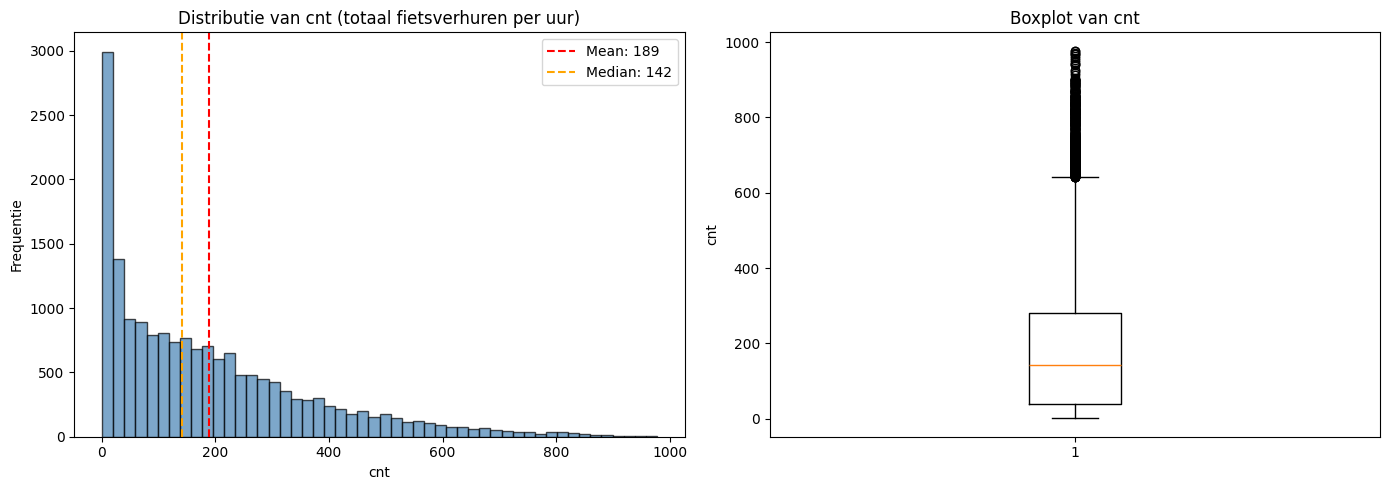

Skewness: 1.277


In [769]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['cnt'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distributie van cnt (totaal fietsverhuren per uur)')
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequentie')
axes[0].axvline(df_clean['cnt'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['cnt'].mean():.0f}")
axes[0].axvline(df_clean['cnt'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['cnt'].median():.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['cnt'], vert=True)
axes[1].set_title('Boxplot van cnt')
axes[1].set_ylabel('cnt')

plt.tight_layout()
plt.show()

# Scheefheid
print(f"Skewness: {df_clean['cnt'].skew():.3f}")


**Interpretatie:**
- De distributie van `cnt` is **rechtsscheef** (skewness = 1.277): de meeste uren hebben relatief weinig verhuren, terwijl een kleiner aantal uren piekwaarden laat zien
- Het gemiddelde (189) ligt hoger dan de mediaan (142), wat de scheefheid bevestigt
- De boxplot toont uitschieters aan de bovenkant — dit zijn drukke uren (bijv. spits)
- We houden deze scheefheid voorlopig in gedachten; als lineaire modellen slecht presteren kan een log-transformatie overwogen worden

### 5.2 Relatie tussen features en target

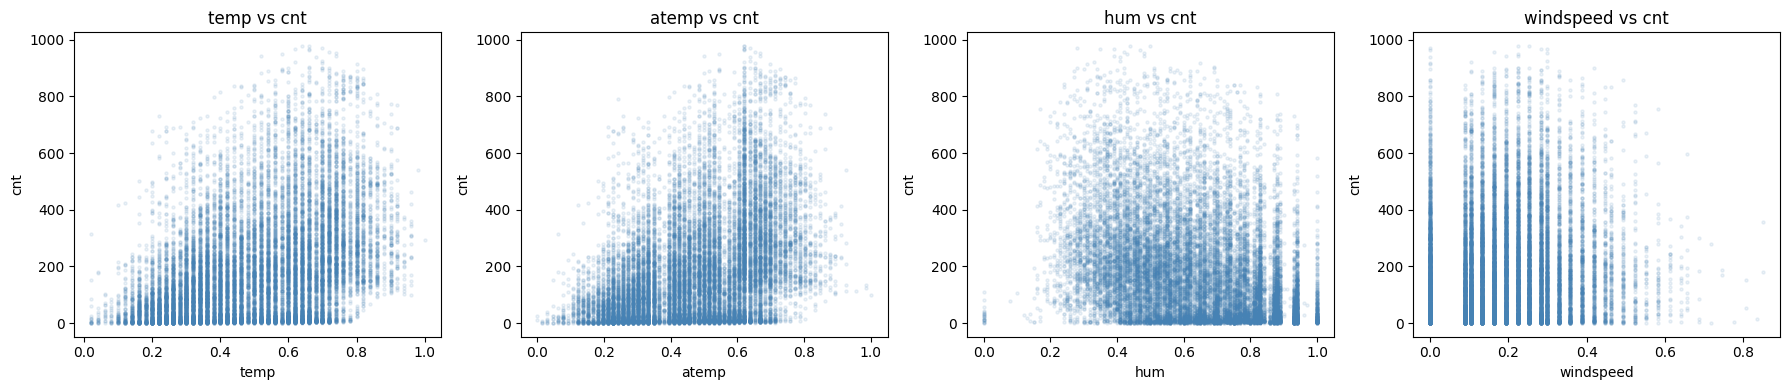

In [770]:
# Scatterplots: numerieke features vs cnt
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(numerical_features):
    axes[i].scatter(df_clean[col], df_clean['cnt'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('cnt')
    axes[i].set_title(f'{col} vs cnt')

plt.tight_layout()
plt.show()

**Interpretatie scatterplots:**
- **`temp`** en **`atemp`** tonen een duidelijk positief verband met het totaal aantal fietsverhuren — bij hogere temperatuur worden meer fietsen verhuurd
- **`hum`** (luchtvochtigheid) toont een licht negatief verband — hogere vochtigheid lijkt samen te gaan met minder fietsverhuren
- **`windspeed`** toont geen sterk lineair verband met het totaal aantal fietsverhuren

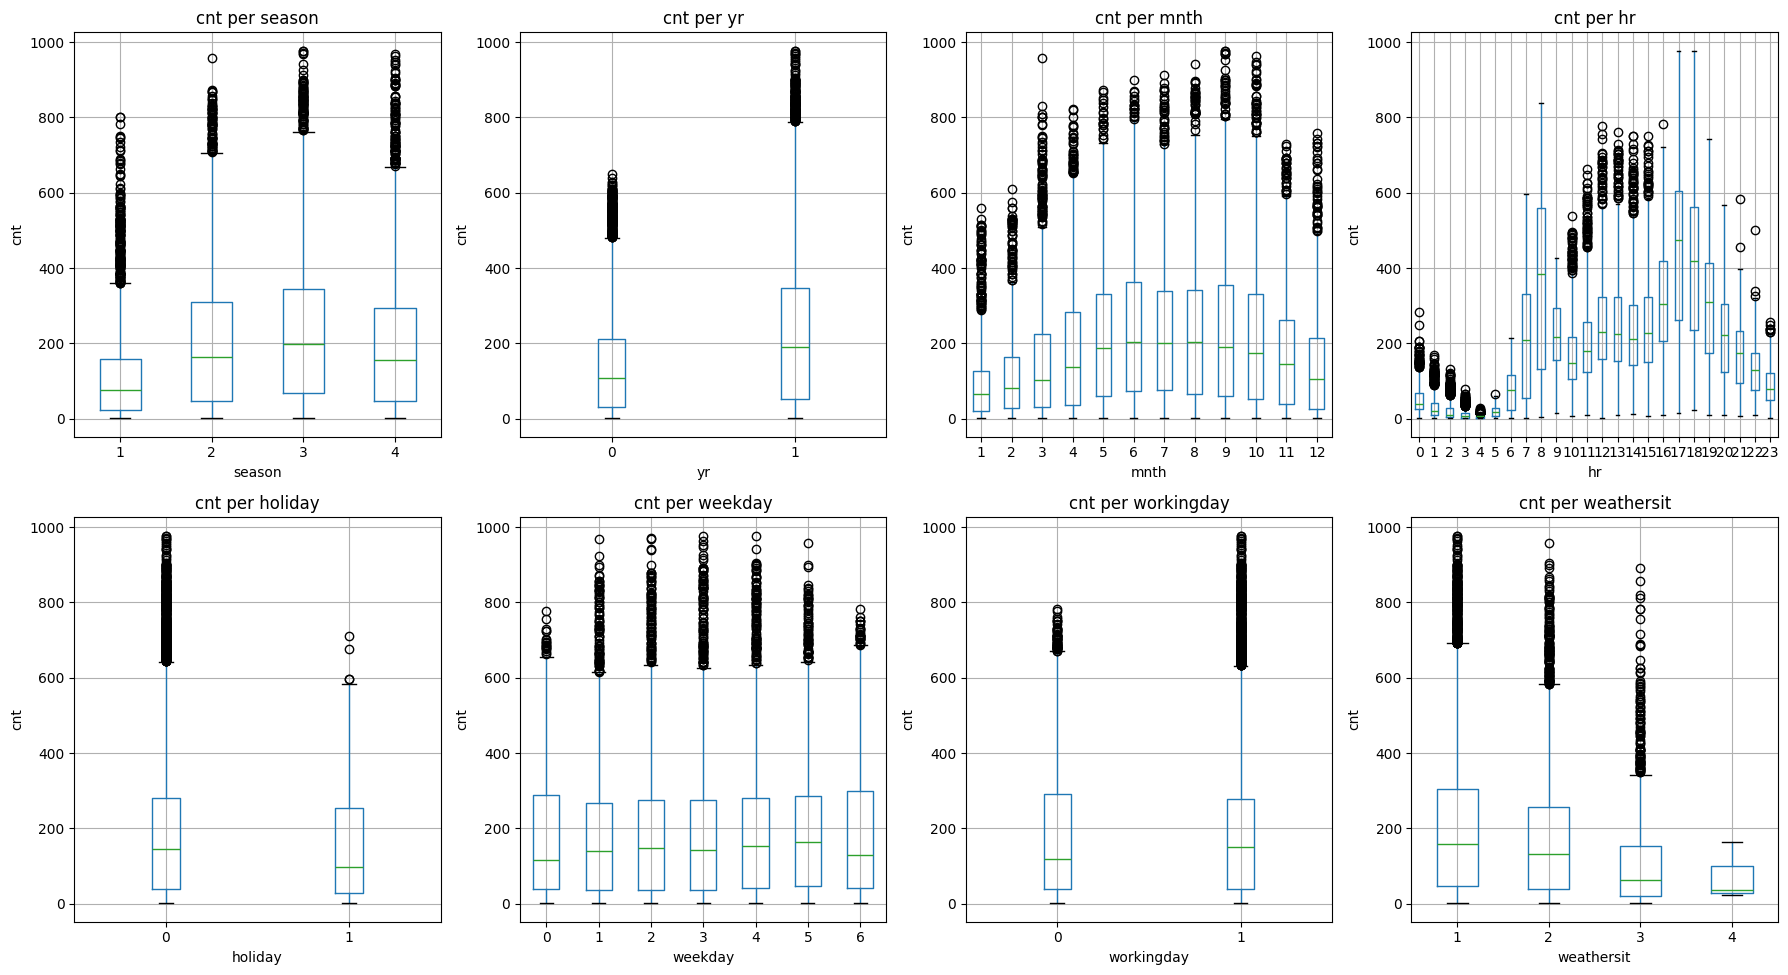

In [771]:
# Boxplots: categorische features vs cnt
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    df_clean.boxplot(column='cnt', by=col, ax=axes[i])
    axes[i].set_title(f'cnt per {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('cnt')

plt.suptitle('')  # Verwijder automatische titel
plt.tight_layout()
plt.show()

**Interpretatie boxplots:**
- **`hr`** (uur) laat een sterk patroon zien met twee pieken in het totaal aantal fietsverhuren: ochtendspits (~8u) en avondspits (~17-18u)
- **`season`** toont dat herfst (3) en zomer (2) de meeste fietsverhuren hebben
- **`yr`** laat zien dat 2012 meer fietsverhuren had dan 2011 — het systeem groeide
- **`weathersit`** bevestigt dat helder weer (1) de meeste fietsverhuren oplevert
- **`workingday`** en **`holiday`** tonen beperkte maar zichtbare verschillen

### 5.3 Correlatiematrix

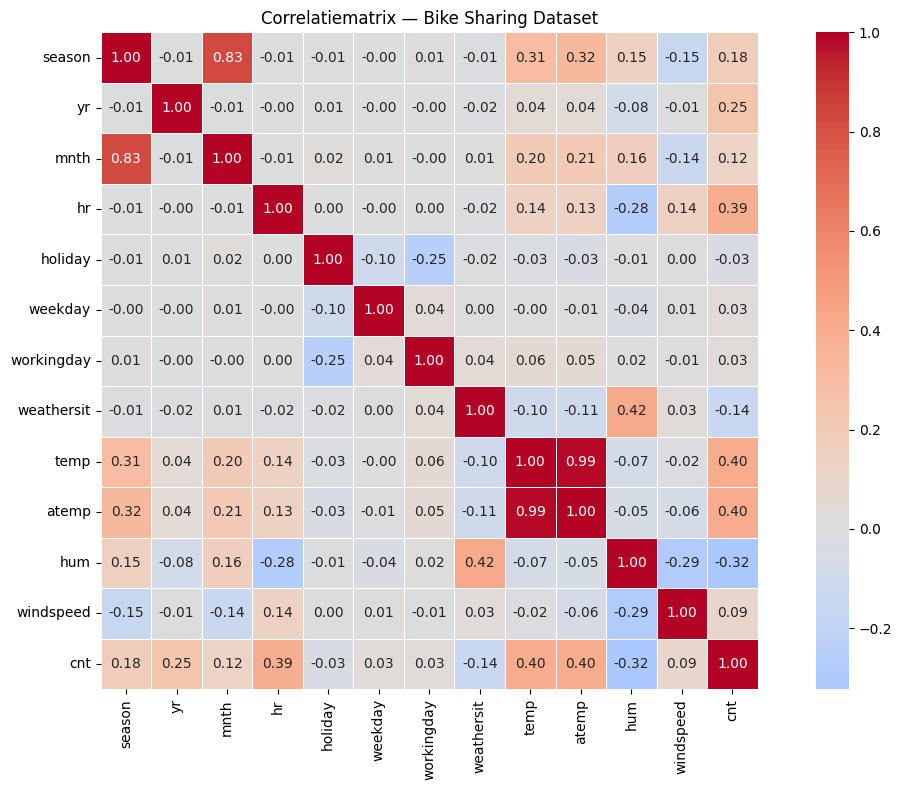

In [772]:
# Correlatiematrix berekenen
correlation_matrix = df_clean.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlatiematrix — Bike Sharing Dataset')
plt.tight_layout()
plt.show()

**Interpretatie correlatiematrix:**

*Correlatie met het totaal aantal fietsverhuren (`cnt`):*
- **`hr`** (0.39) — sterkste correlatie, het uur van de dag is de belangrijkste voorspeller
- **`temp`** (0.40) en **`atemp`** (0.40) — warmer weer leidt tot meer fietsverhuren
- **`hum`** (-0.32) — negatieve correlatie, hogere luchtvochtigheid betekent minder fietsverhuren
- **`yr`** (0.25) — in 2012 waren er meer fietsverhuren dan in 2011
- **`weathersit`** (-0.14) — slechter weer hangt samen met minder fietsverhuren
- **`holiday`** (-0.03) en **`weekday`** (0.03) — vrijwel geen lineaire correlatie

*Multicollineariteit:*
- **`temp`** en **`atemp`** zijn onderling zeer sterk gecorreleerd (0.99) — dit is een duidelijk signaal van multicollineariteit. Eén van deze twee zal waarschijnlijk verwijderd moeten worden
- **`season`** en **`mnth`** zijn ook sterk gecorreleerd (0.83) — logisch, want het seizoen wordt bepaald door de maand. Dit wordt verder onderzocht met VIF

### 5.4 Multicollineariteit — VIF analyse

Uit de correlatiematrix blijkt dat `temp` en `atemp` zeer sterk gecorreleerd zijn (0.99), en `season` en `mnth` ook (0.83). Om multicollineariteit formeel te diagnosticeren berekenen we de VIF (Variance Inflation Factor) voor elke feature.

Volgens de theorie geldt:
- **VIF > 10** → multicollineariteit is problematisch
- **Tolerance < 0.1** → zelfde conclusie (Tolerance = 1 / VIF)

In [773]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Features opnieuw definiëren
features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 
'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

X = df_clean[features]

# VIF berekenen voor alle features
vif_data = pd.DataFrame()
vif_data['Feature'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data['Tolerance'] = 1 / vif_data['VIF']
vif_data = vif_data.sort_values('VIF', ascending=False)

print("VIF-analyse (Variance Inflation Factor):\n")
print(vif_data.to_string(index=False))

VIF-analyse (Variance Inflation Factor):

   Feature        VIF  Tolerance
     atemp 354.508062   0.002821
      temp 320.356672   0.003122
    season  21.133523   0.047318
      mnth  15.159659   0.065965
       hum  12.206201   0.081926
weathersit   7.599369   0.131590
        hr   3.822101   0.261636
 windspeed   3.258951   0.306847
workingday   3.236161   0.309008
   weekday   3.058983   0.326906
        yr   1.945772   0.513935
   holiday   1.095694   0.912663


**Interpretatie VIF-analyse:**
- **`atemp`** (VIF = 354.5) en **`temp`** (VIF = 320.4) — extreem hoge VIF, ver boven de drempel van 10. Dit bevestigt de sterke multicollineariteit die we in de correlatiematrix zagen (r = 0.99)
- **`season`** (VIF = 21.1) en **`mnth`** (VIF = 15.2) — ook boven de drempel van 10, logisch omdat seizoen direct afgeleid is van de maand
- **`hum`** (VIF = 12.2) — net boven de drempel
- Alle overige features hebben een VIF onder 10 — geen probleem

**Beslissing:** We verwijderen `atemp` omdat deze vrijwel identieke informatie bevat als `temp`. We herberekenen daarna de VIF om te controleren of het probleem is opgelost.

In [774]:
# atemp verwijderen
features_clean = [f for f in features if f != 'atemp']

X_clean = df_clean[features_clean]

# VIF opnieuw berekenen
vif_data2 = pd.DataFrame()
vif_data2['Feature'] = features_clean
vif_data2['VIF'] = [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])]
vif_data2['Tolerance'] = 1 / vif_data2['VIF']
vif_data2 = vif_data2.sort_values('VIF', ascending=False)

print("VIF na verwijdering van atemp:\n")
print(vif_data2.to_string(index=False))

VIF na verwijdering van atemp:

   Feature       VIF  Tolerance
    season 21.058491   0.047487
      mnth 15.156499   0.065978
       hum 11.441489   0.087401
      temp  8.023689   0.124631
weathersit  7.594574   0.131673
        hr  3.754495   0.266347
workingday  3.227974   0.309792
 windspeed  3.213348   0.311202
   weekday  3.056419   0.327180
        yr  1.940106   0.515436
   holiday  1.095684   0.912672


**Na verwijdering van `atemp`:**
- `temp` is gezakt van 320.4 naar 8.0 — probleem opgelost
- `season` (21.1) en `mnth` (15.2) zitten nog boven 10 — logisch, want seizoen is afgeleid van de maand
- `hum` (11.4) zit net boven de drempel

**Beslissing:** We verwijderen ook `season` omdat `mnth` meer gedetailleerde informatie bevat (12 maanden vs 4 seizoenen). Hierna controleren we de VIF opnieuw.

In [775]:
# season ook verwijderen
features_final = [f for f in features_clean if f != 'season']

X_final = df_clean[features_final]

# VIF opnieuw berekenen
vif_data3 = pd.DataFrame()
vif_data3['Feature'] = features_final
vif_data3['VIF'] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
vif_data3['Tolerance'] = 1 / vif_data3['VIF']
vif_data3 = vif_data3.sort_values('VIF', ascending=False)

print("VIF na verwijdering van atemp en season:\n")
print(vif_data3.to_string(index=False))

VIF na verwijdering van atemp en season:

   Feature       VIF  Tolerance
       hum 11.243526   0.088940
weathersit  7.593278   0.131695
      temp  7.190904   0.139065
      mnth  4.907799   0.203757
        hr  3.752996   0.266454
workingday  3.224596   0.310116
 windspeed  3.213313   0.311205
   weekday  3.056043   0.327220
        yr  1.939806   0.515516
   holiday  1.095160   0.913109


**Conclusie VIF-analyse:**

Na het verwijderen van `atemp` en `season` zijn bijna alle VIF-waarden onder 10. Alleen `hum` (11.2) zit net boven de drempel. Omdat luchtvochtigheid inhoudelijk een relevante voorspeller is voor het totaal aantal fietsverhuren, en de waarde slechts marginaal boven de grens ligt, behouden we deze feature.

**Definitieve featureset (10 features):**  
`yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `hum`, `windspeed`

**Verwijderd vanwege multicollineariteit:**
- `atemp` (VIF = 354.5) — vrijwel identiek aan `temp`
- `season` (VIF = 21.1) — overlappend met `mnth`

## 6. Baseline Linear Regression Model

We beginnen met een standaard Linear Regression als baseline. Dit geeft een referentiepunt waartegen we latere modellen kunnen vergelijken. We gebruiken de definitieve featureset na de VIF-analyse.

In [776]:
# Definitieve features en target
X = df_clean[features_final]
y = df_clean['cnt']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features: {features_final}")
print(f"Aantal features: {len(features_final)}")
print(f"\nTraining set: {X_train.shape[0]} rijen")
print(f"Test set: {X_test.shape[0]} rijen")

Features: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']
Aantal features: 10

Training set: 13903 rijen
Test set: 3476 rijen


In [777]:
# Pipeline met scaling en Linear Regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Model trainen
pipeline_lr.fit(X_train, y_train)

# Voorspellingen maken
y_pred_lr = pipeline_lr.predict(X_test)

# Evaluatie
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

print("=== Baseline: Linear Regression ===")
print(f"R² score:  {r2_lr:.4f}")
print(f"RMSE:      {rmse_lr:.2f}")
print(f"\nHet model verklaart {r2_lr*100:.1f}% van de variatie in het totaal aantal fietsverhuren")
print(f"De gemiddelde voorspelfout is {rmse_lr:.0f} fietsverhuren per uur")

=== Baseline: Linear Regression ===
R² score:  0.3825
RMSE:      139.84

Het model verklaart 38.2% van de variatie in het totaal aantal fietsverhuren
De gemiddelde voorspelfout is 140 fietsverhuren per uur


### Interpretatie baseline model

- **R² = 0.38** — het model verklaart slechts 38.2% van de variatie in het totaal aantal fietsverhuren. Dit is een zwak resultaat
- **RMSE = 140** — de gemiddelde voorspelfout is 140 fietsverhuren per uur, wat hoog is ten opzichte van het gemiddelde (189)

Dit zwakke resultaat is niet verrassend: uit de EDA bleek al dat het uur van de dag (`hr`) een sterk niet-lineair patroon heeft met twee spitspieken. Een standaard lineair model kan dit niet goed vangen. Dit motiveert het gebruik van meer geavanceerde modellen in de volgende stappen.

Eerst controleren we de regressie-assumpties om formeel te bevestigen waar het model tekortschiet.

## 7. Assumption Checking

We controleren de vier regressie-assumpties op het baseline model:
1. **Linearity** — residual plot mag geen gebogen patroon tonen
2. **Normality of residuals** — QQ-plot en Shapiro-Wilk test
3. **Homoscedasticity** — residual plot moet gelijkmatige spreiding tonen
4. **Multicollinearity** — reeds gecontroleerd met VIF in sectie 5.4

In [778]:
# Residuals berekenen
residuals = y_test - y_pred_lr

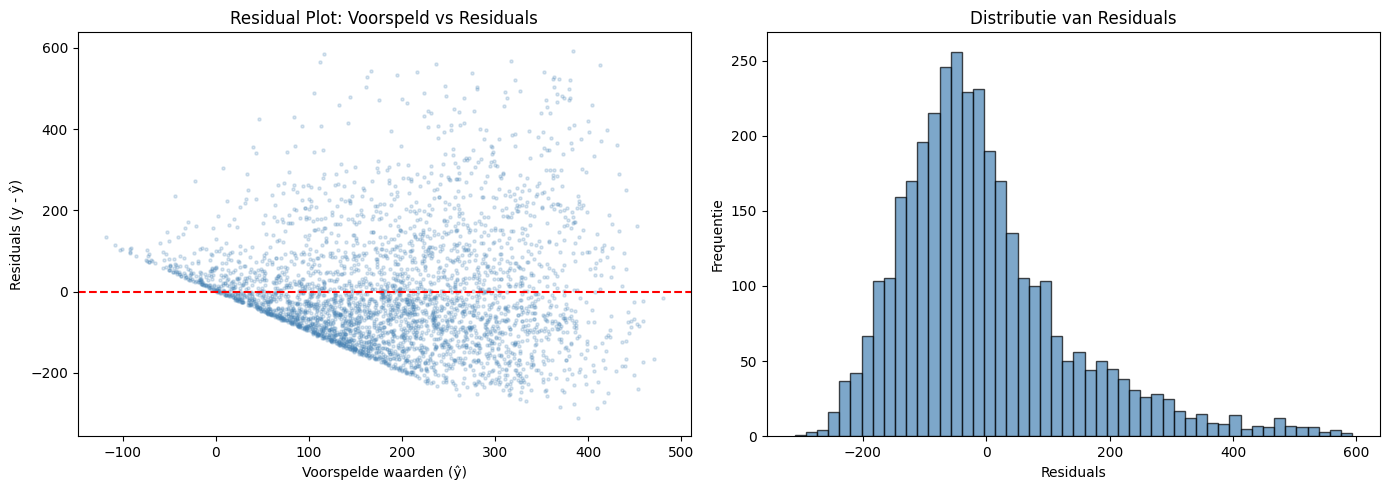

In [779]:
# Residual plot: predicted vs residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Residuals
axes[0].scatter(y_pred_lr, residuals, alpha=0.2, s=5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Voorspelde waarden (ŷ)')
axes[0].set_ylabel('Residuals (y - ŷ)')
axes[0].set_title('Residual Plot: Voorspeld vs Residuals')

# Plot 2: Histogram van residuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequentie')
axes[1].set_title('Distributie van Residuals')

plt.tight_layout()
plt.show()

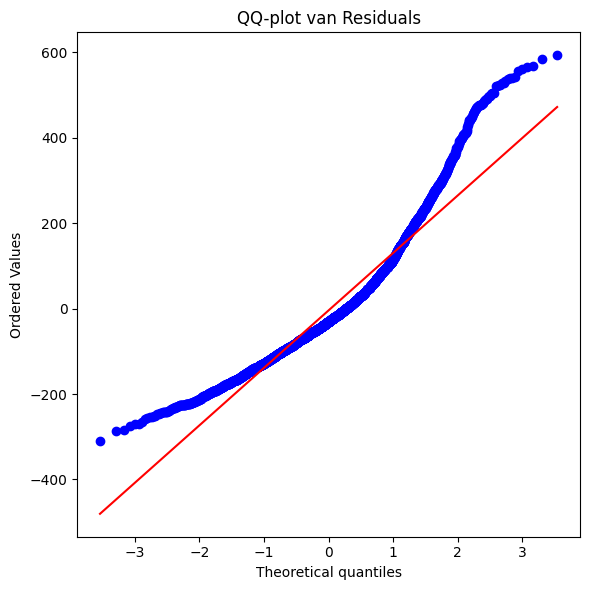

In [780]:
import scipy.stats as stats

# QQ-plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('QQ-plot van Residuals')
plt.tight_layout()
plt.show()

In [781]:
# Shapiro-Wilk test (op een sample, want de test werkt het best met max 5000 observaties)
sample_residuals = residuals.sample(n=min(5000, len(residuals)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)

print("=== Shapiro-Wilk Test voor Normaliteit van Residuals ===")
print(f"Test statistiek: {shapiro_stat:.4f}")
print(f"P-waarde:        {shapiro_p:.6f}")
print()
if shapiro_p < 0.05:
    print("Conclusie: p < 0.05 — we verwerpen H0.")
    print("De residuals zijn NIET normaal verdeeld.")
else:
    print("Conclusie: p >= 0.05 — we kunnen H0 niet verwerpen.")
    print("Er is onvoldoende bewijs dat de residuals niet normaal verdeeld zijn.")

=== Shapiro-Wilk Test voor Normaliteit van Residuals ===
Test statistiek: 0.9238
P-waarde:        0.000000

Conclusie: p < 0.05 — we verwerpen H0.
De residuals zijn NIET normaal verdeeld.


### Interpretatie Assumption Checking

**1. Linearity:**
- De residual plot toont een duidelijk patroon (waaiersvorm) — geen random scatter
- De linearity assumptie is geschonden

**2. Homoscedasticity:**
- De spreiding van residuals neemt toe bij hogere voorspelde waarden (funnel shape)
- Dit wijst op heteroscedasticity — de assumptie is geschonden

**3. Normality of residuals:**
- Het histogram toont een rechtscheve verdeling
- De QQ-plot wijkt sterk af van de diagonaal, vooral in de staarten
- Shapiro-Wilk test: p < 0.001 — we verwerpen H0, de residuals zijn NIET normaal verdeeld

**4. Multicollinearity:**
- Afgehandeld in sectie 5.4 — `atemp` en `season` verwijderd na VIF-analyse

**Conclusie:** Het lineaire regressiemodel schendt de assumpties van linearity, homoscedasticity en normality. Dit bevestigt dat een standaard lineair model niet geschikt is voor deze data. In de volgende stap trainen we Ridge Regression en Gradient Boosting als alternatieven. Ridge kan helpen bij multicollineariteit, en Gradient Boosting vereist geen lineaire assumpties.

## 8. Model Training en Vergelijking

We trainen twee aanvullende modellen naast de baseline Linear Regression:
- **Ridge Regression** — lineair model met regularisatie, helpt bij multicollineariteit
- **Gradient Boosting Regressor** — tree-based model dat niet-lineaire relaties kan vangen zonder de assumpties van lineaire regressie

In [782]:
# Ridge Regression
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)

print("=== Ridge Regression ===")
print(f"R² score:  {r2_ridge:.4f}")
print(f"RMSE:      {rmse_ridge:.2f}")

=== Ridge Regression ===
R² score:  0.3825
RMSE:      139.84


In [783]:
# Gradient Boosting Regressor
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
])

pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = root_mean_squared_error(y_test, y_pred_gb)

print("=== Gradient Boosting Regressor ===")
print(f"R² score:  {r2_gb:.4f}")
print(f"RMSE:      {rmse_gb:.2f}")

=== Gradient Boosting Regressor ===
R² score:  0.9414
RMSE:      43.09


In [784]:
# Vergelijkingstabel
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Gradient Boosting'],
    'R²': [r2_lr, r2_ridge, r2_gb],
    'RMSE': [rmse_lr, rmse_ridge, rmse_gb]
})

results = results.sort_values('R²', ascending=False)
print("=== Model Vergelijking ===\n")
print(results.to_string(index=False))

=== Model Vergelijking ===

            Model       R²       RMSE
Gradient Boosting 0.941356  43.092807
 Ridge Regression 0.382465 139.837424
Linear Regression 0.382464 139.837478


### Interpretatie modelvergelijking

| Model | R² | RMSE |
|-------|-----|------|
| Gradient Boosting | 0.9414 | 43.09 |
| Ridge Regression | 0.3825 | 139.84 |
| Linear Regression | 0.3825 | 139.84 |

**Conclusie:**
- **Gradient Boosting** presteert verreweg het beste met R² = 0.94 en RMSE = 43. Het model verklaart 94.1% van de variatie in het totaal aantal fietsverhuren
- **Ridge Regression** presteert nagenoeg identiek aan Linear Regression (R² = 0.38) — regularisatie helpt hier niet, omdat het probleem niet multicollineariteit is maar het niet-lineaire karakter van de data
- De lineaire modellen schenden meerdere assumpties (aangetoond in sectie 7), wat hun lage prestatie verklaart
- **Gradient Boosting** is een tree-based model dat geen lineaire assumpties vereist en niet-lineaire patronen (zoals het spitspatroon in `hr`) goed kan vangen

**Beste model: Gradient Boosting Regressor**

## 9. Feature Selection met Pairwise Regression

De opdracht vereist feature selection met pairwise regression. Hierbij trainen we een apart regressiemodel voor elke individuele feature tegen de target. Dit toont welke features individueel de meeste voorspellende waarde hebben voor het totaal aantal fietsverhuren.

In [785]:
# Pairwise regression: elke feature apart tegen cnt
pairwise_results = []

for feature in features_final:
    X_single = X_train[[feature]]
    X_single_test = X_test[[feature]]
    
    model = LinearRegression()
    model.fit(X_single, y_train)
    y_pred = model.predict(X_single_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    pairwise_results.append({
        'Feature': feature,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 2)
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('R²', ascending=False)
print("=== Pairwise Regression Results ===\n")
print(pairwise_df.to_string(index=False))

=== Pairwise Regression Results ===

   Feature      R²   RMSE
      temp  0.1674 162.37
        hr  0.1617 162.92
       hum  0.0991 168.90
        yr  0.0510 173.35
weathersit  0.0167 176.46
 windspeed  0.0110 176.97
      mnth  0.0063 177.39
workingday  0.0006 177.90
   weekday -0.0007 178.01
   holiday -0.0009 178.03


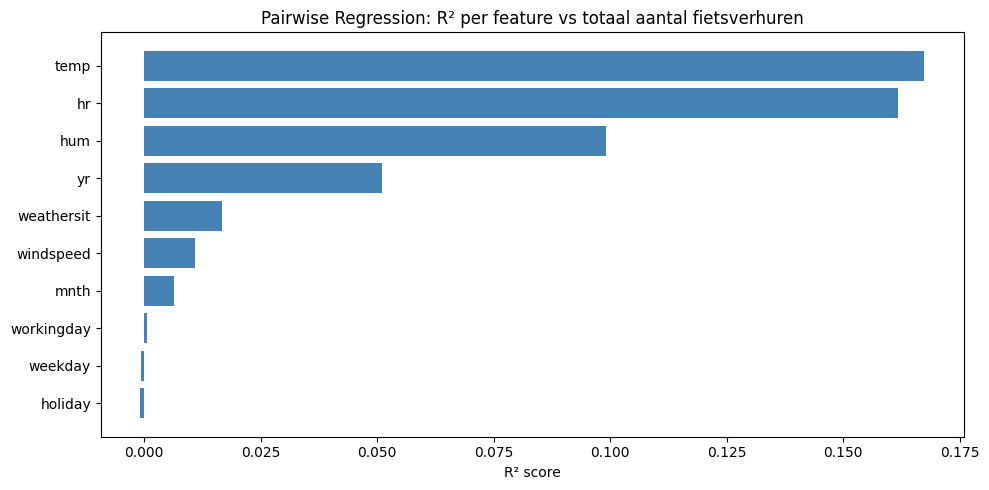

In [786]:
# Barplot van R² per feature
plt.figure(figsize=(10, 5))
plt.barh(pairwise_df['Feature'], pairwise_df['R²'], color='steelblue')
plt.xlabel('R² score')
plt.title('Pairwise Regression: R² per feature vs totaal aantal fietsverhuren')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretatie Pairwise Regression

De pairwise regression toont de individuele voorspellende kracht van elke feature:

- **`temp`** (R² = 0.17) — individueel de sterkste voorspeller voor het totaal aantal fietsverhuren
- **`hr`** (R² = 0.16) — bijna even sterk. Let op: `hr` heeft een niet-lineair patroon (twee spitspieken), waardoor een lineaire pairwise regression de werkelijke kracht van deze feature onderschat
- **`hum`** (R² = 0.10) — luchtvochtigheid heeft een negatief effect
- **`yr`** (R² = 0.05) — het systeem groeide van 2011 naar 2012
- **`weekday`** en **`holiday`** hebben individueel vrijwel geen lineaire voorspellende waarde (R² ≈ 0)

**Opmerking:** Pairwise regression meet alleen het individuele *lineaire* effect. In een Gradient Boosting model werken features samen en worden niet-lineaire patronen wel gevangen. Daarom behouden we alle features — ook die met een lage individuele R².

## 10. Beste Model: Retraining en Opslaan

Gradient Boosting is het beste model (R² = 0.94, RMSE = 43.09). Volgens de opdracht moeten we het beste model retrainen op de volledige trainingsdata en opslaan.

In [787]:
import joblib

# Beste model retrainen op volledige trainingsdata
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
])

final_model.fit(X_train, y_train)

# Verificatie op test set
y_pred_final = final_model.predict(X_test)
r2_final = r2_score(y_test, y_pred_final)
rmse_final = root_mean_squared_error(y_test, y_pred_final)

print("=== Final Model: Gradient Boosting (retrained) ===")
print(f"R² score:  {r2_final:.4f}")
print(f"RMSE:      {rmse_final:.2f}")
print(f"\nGebruikte features: {features_final}")

=== Final Model: Gradient Boosting (retrained) ===
R² score:  0.9414
RMSE:      43.09

Gebruikte features: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']


In [788]:
# Model opslaan
joblib.dump(final_model, '../modellen/model.joblib')

# Features opslaan (nodig voor de Streamlit app)
joblib.dump(features_final, '../modellen/features.joblib')

print("Model opgeslagen als: modellen/model.joblib")
print("Features opgeslagen als: modellen/features.joblib")

Model opgeslagen als: modellen/model.joblib
Features opgeslagen als: modellen/features.joblib


In [789]:
# Verificatie: model laden en testen
loaded_model = joblib.load('../modellen/model.joblib')
loaded_features = joblib.load('../modellen/features.joblib')

y_pred_loaded = loaded_model.predict(X_test)
print(f"Verificatie na laden — R²: {r2_score(y_test, y_pred_loaded):.4f}")
print(f"Features: {loaded_features}")

Verificatie na laden — R²: 0.9414
Features: ['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']


### Conclusie

Het Gradient Boosting model is geretrained en opgeslagen als `model.joblib`. De features zijn opgeslagen als `features.joblib` zodat de Streamlit applicatie weet welke invoer nodig is.

Het model verklaart 94.1% van de variatie in het totaal aantal fietsverhuren per uur met een gemiddelde voorspelfout van ~43 fietsverhuren.